This is the original exploratory notebook, kept as-is as the source of truth this project was refactored from. It is frozen and superseded by `src/`, `configs/train.yaml`, and `notebooks/00_eda.ipynb` / `01_baseline_training.ipynb` — see the top-level README for the current pipeline.

In [347]:
import time
from pyexpat import features

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer
from sklearn.linear_model import Ridge, Lasso, LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder



plt.style.use('default')

In [348]:
df = pd.read_csv('./data/train.csv')

print(df.shape)
df = df.drop(columns=['Id'])
df.head()

(1460, 81)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [349]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [350]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [351]:
df.isna().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [352]:

df.value_counts(subset=['MSZoning', 'Street'])

MSZoning  Street
RL        Pave      1148
RM        Pave       217
FV        Pave        65
RH        Pave        16
C (all)   Pave         8
RL        Grvl         3
C (all)   Grvl         2
RM        Grvl         1
Name: count, dtype: int64

In [353]:
df.dtypes

MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 80, dtype: object

In [354]:
def histogram_multiple(df, cols, fig_size_x, fig_size_y, n_rows, n_cols):
    plt.figure(figsize=(fig_size_x, fig_size_y))

    for (i, col) in enumerate(cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        plt.hist(x=df[col], bins=20)
        plt.xlabel(col)
        plt.title(col + ' Distribution')


    plt.show()


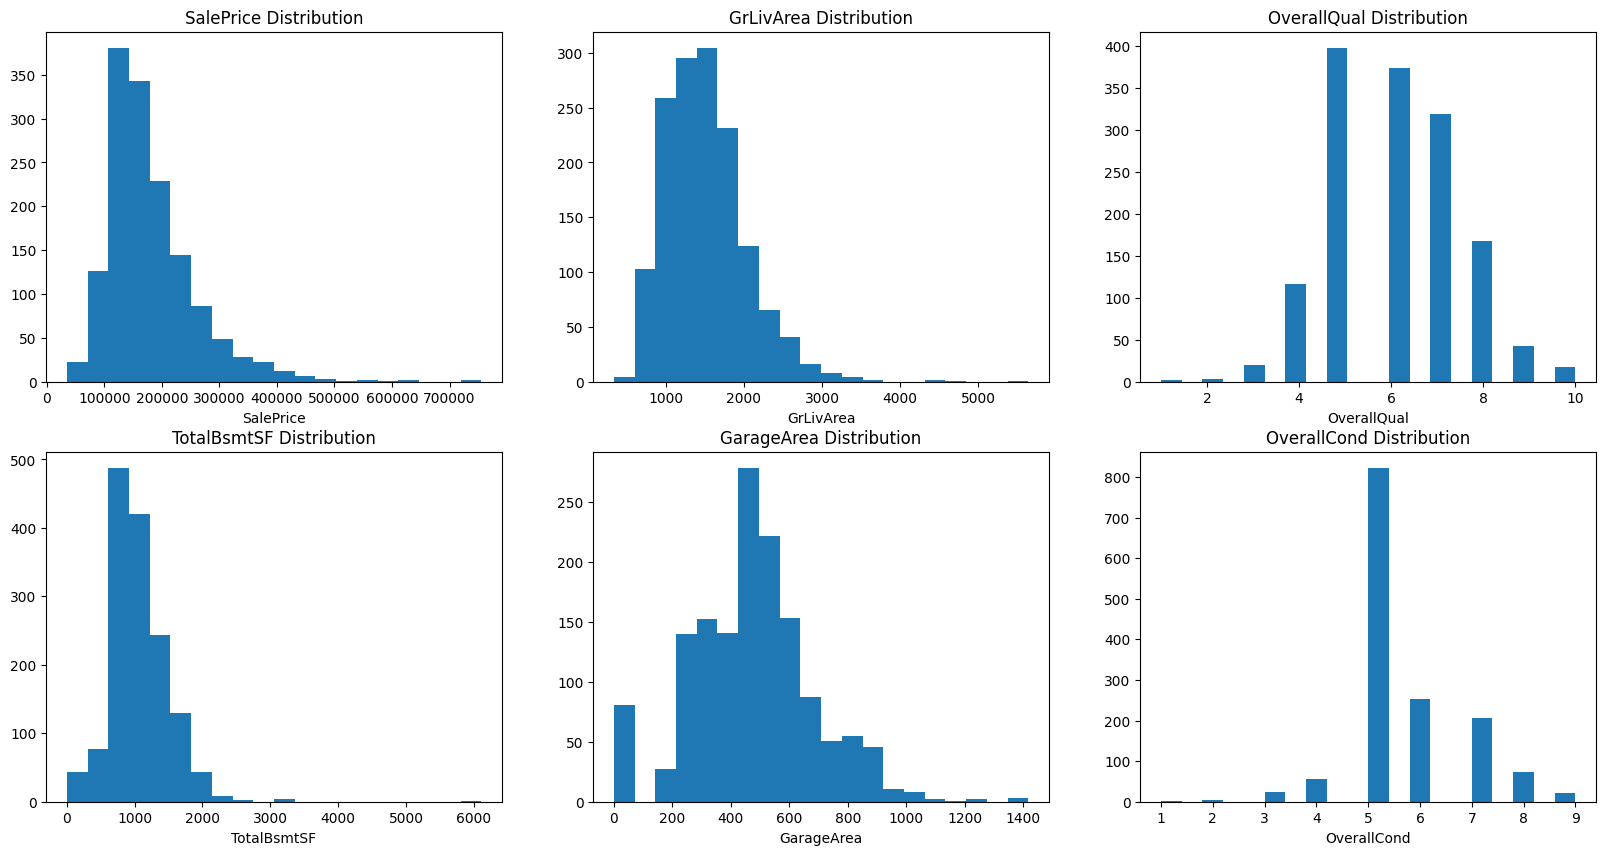

In [355]:
hist_plot_columns = ['SalePrice','GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageArea', 'OverallCond']

histogram_multiple(df, hist_plot_columns, fig_size_x=20, fig_size_y=10, n_cols=3, n_rows=2)

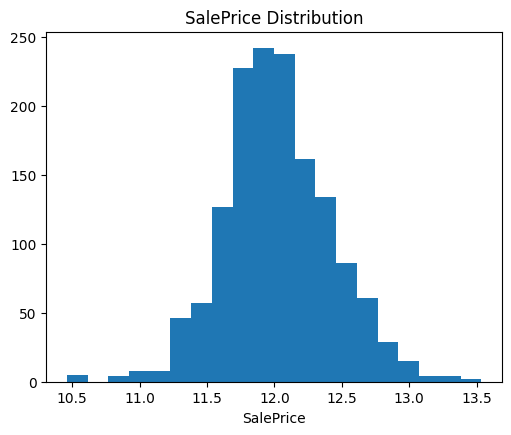

In [356]:
sale_hist = ['SalePrice']
df['SalePrice'] = np.log1p(df['SalePrice'])
histogram_multiple(df, sale_hist, fig_size_x=20, fig_size_y=10, n_cols=3, n_rows=2)

In [357]:
def box_plot_multiple(df, cols, fig_size_x, fig_size_y, n_rows, n_cols):
    plt.figure(figsize=(fig_size_x, fig_size_y))

    for (i, col) in enumerate(cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        plt.boxplot(x=df[col])
        plt.xlabel(col)
        plt.title(col + ' Distribution')


    plt.show()

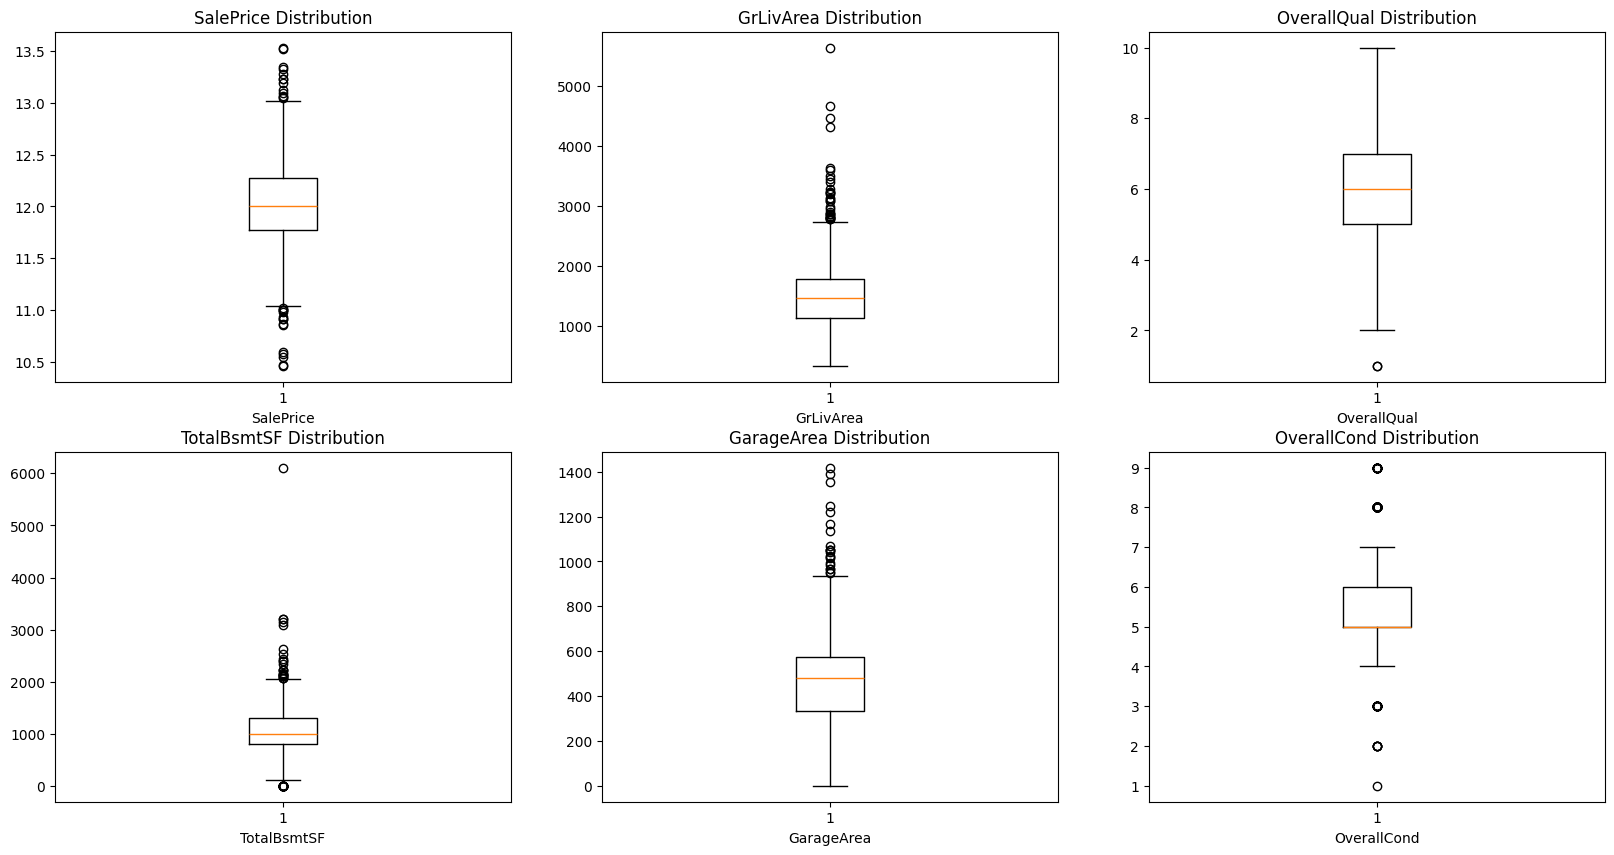

In [358]:
box_plot_multiple(df ,hist_plot_columns, fig_size_x=20, fig_size_y=10, n_cols=3, n_rows=2)

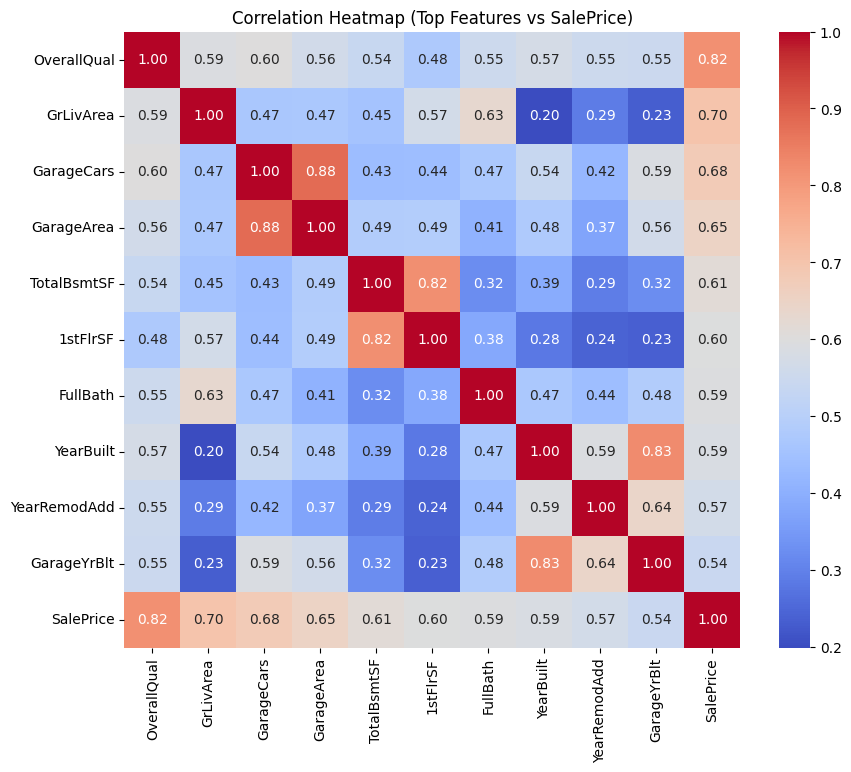

In [359]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
corr_arr = (df_numeric.corr()['SalePrice']).drop('SalePrice')
corr_top_10 = (corr_arr.abs().sort_values(ascending=False)).head(10)
df_corr = df_numeric[corr_top_10.index.tolist()+ ['SalePrice']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Heatmap (Top Features vs SalePrice)")
plt.show()

In [360]:
DROPPED_COLUMNS = ['Street', 'Alley', 'Utilities', 'Condition2', 'RoofMatl', 'Heating', 'PoolQC', 'PoolArea', 'MiscFeature', 'Fence', 'MiscVal']#Alley

categorial_columns = ['MasVnrType','BsmtQual', 'BsmtCond', 'BsmtFinType1','BsmtFinType2','FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'Fence', 'MiscFeature', 'Alley', 'PoolQC' ]
numeric_columns = ['MasVnrArea', 'GarageYrBlt', 'BsmtFinSF2']

imputer = KNNImputer(n_neighbors=5, weights='distance')

f_imputed = imputer.fit_transform(df_numeric)
df['LotFrontage'] = f_imputed[:, df_numeric.columns.get_loc('LotFrontage')]
df['BsmtExposure'] = df['BsmtExposure'].fillna("No")
df = df.dropna(subset=['Electrical'])

df[categorial_columns] = df[categorial_columns].fillna("None")
df[numeric_columns] = df[numeric_columns].fillna(0)


filtered_df =  df.drop(columns=DROPPED_COLUMNS)


In [361]:
X = filtered_df.drop(columns=['SalePrice'])
Y = filtered_df['SalePrice']

cat_columns = X.select_dtypes(include=['object']).columns
num_columns = X.select_dtypes(include=['int64', 'float64']).columns

# for col in cat_columns:
#     X[col] = X[col].astype('category').cat.codes

X_train,  X_test,Y_train, Y_test = train_test_split(X, Y, test_size=0.3 , random_state=42, shuffle=True)


In [362]:
scaler = StandardScaler()
X_train_num_array = scaler.fit_transform(X_train[num_columns])
X_test_num_array = scaler.transform(X_test[num_columns])


X_train_num = pd.DataFrame(X_train_num_array, columns=num_columns, index=X_train.index)
X_test_num = pd.DataFrame(X_test_num_array, columns=num_columns, index=X_test.index)



In [363]:
one = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_array = one.fit_transform(X_train[cat_columns])
X_test_cat_array = one.transform(X_test[cat_columns])

one_columns = one.get_feature_names_out(cat_columns)

X_train_cat = pd.DataFrame(X_train_cat_array, columns=one_columns, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat_array, columns=one_columns, index=X_test.index)

In [364]:


X_train_transformed = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_transformed = pd.concat([X_test_num, X_test_cat], axis=1)

In [365]:
def model_scores(model, grid_params, Y_test, X_train, X_test):
    grid = GridSearchCV(model(), param_grid=grid_params, n_jobs=-1, cv=5)
    start_time = time.time()

    grid.fit(X_train, Y_train)

    print('Runtime for grid search: ', (time.time() - start_time))
    print('Best Accuracy Score: \n', grid.best_score_)
    print('Best Parameters: \n', grid.best_params_)

    model = model(**grid.best_params_)
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)

    scores = cross_val_score(model, X_train, Y_train, cv=5)
    print('Score: \n', model.score(X_test, Y_test))
    print('Cross Validation Score: \n', scores)
    print('Avarage Cross Validation Score: \n', scores.mean())

    rmse = mean_squared_error(np.expm1(Y_test), np.expm1(y_pred)) ** 0.5

    print('Root Mean Squared Error', rmse)

In [366]:
models_config = {
    "LinearRegression": {
        "model": LinearRegression,
        "params": {
            'tol': np.logspace(-4, 8, 3),
            'fit_intercept': [True, False],
            'n_jobs': [-1],
        },
        "ravel_y": False
    },

    "KNN": {
        "model": KNeighborsRegressor,
        "params": {
            'n_neighbors': list(range(1, 15, 3)),
            'weights': ['uniform', 'distance'],
            'p': [1, 2],
            'metric': ['chebyshev', 'minkowski'],
            'n_jobs': [-1],
        },
        "ravel_y": False
    },

    "RandomForest": {
        "model": RandomForestRegressor,
        "params": {
            'n_estimators': [100, 200, 500, 1000],
            'max_depth': [None, 5, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10],
            'max_features': ['sqrt', 'log2'],
            'bootstrap': [True, False],
            'random_state': [42],
            'n_jobs': [-1],
        },
        "ravel_y": True
    },

    "Ridge": {
        "model": Ridge,
        "params": {
            'alpha': np.logspace(-4, 8, 3),
            'fit_intercept': [True, False],
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga'],
            'max_iter': [10000, 50000, 100000],
            'tol': [1e-3, 1e-2, 1e-1],
            'random_state': [42]
        },
        "ravel_y": False
    },

    "Lasso": {
        "model": Lasso,
        "params": {
            'alpha': np.logspace(-4, 8, 3),
            'fit_intercept': [True, False],
            'selection': ['random', 'cyclic'],
            'max_iter': [10000, 50000, 100000],
            'tol': [1e-3, 1e-2, 1e-1],
            'random_state': [42]
        },
        "ravel_y": False
    },

    "ElasticNet": {
        "model": ElasticNet,
        "params": {
            'alpha': np.logspace(-2, 3, 6),
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1],
            'fit_intercept': [True, False],
            'tol': [1e-4, 1e-3, 1e-2],
            'selection': ['cyclic', 'random'],
            'max_iter': [100000, 200000, 300000],
            'random_state': [42]
        },
        "ravel_y": False
    }
}

In [367]:
for name, cfg in models_config.items():
    print('\n' +'_'*10 + name + '_'*10 +'\n')

    y = Y_test.values.ravel() if cfg['ravel_y'] else Y_test

    model_scores(cfg['model'], cfg['params'], y, X_train_transformed, X_test_transformed)


__________LinearRegression__________

Runtime for grid search:  1.8981075286865234
Best Accuracy Score: 
 0.7947377244410262
Best Parameters: 
 {'fit_intercept': True, 'n_jobs': -1, 'tol': np.float64(0.0001)}
Score: 
 0.8858932704870449
Cross Validation Score: 
 [0.85906428 0.55251423 0.87172141 0.84396468 0.84642401]
Avarage Cross Validation Score: 
 0.7947377244410259
Root Mean Squared Error 26595.280161055187

__________KNN__________

Runtime for grid search:  0.9835538864135742
Best Accuracy Score: 
 0.8102035877121555
Best Parameters: 
 {'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Score: 
 0.8155886936134791
Cross Validation Score: 
 [0.81827663 0.79777722 0.79426456 0.80663461 0.83406492]
Avarage Cross Validation Score: 
 0.8102035877121555
Root Mean Squared Error 34205.580919152366

__________RandomForest__________

Runtime for grid search:  518.404801607132
Best Accuracy Score: 
 0.8537043380695861
Best Parameters: 
 {'bootstrap': Fal

[145   6  12  25  24  26  11   5  15   3]


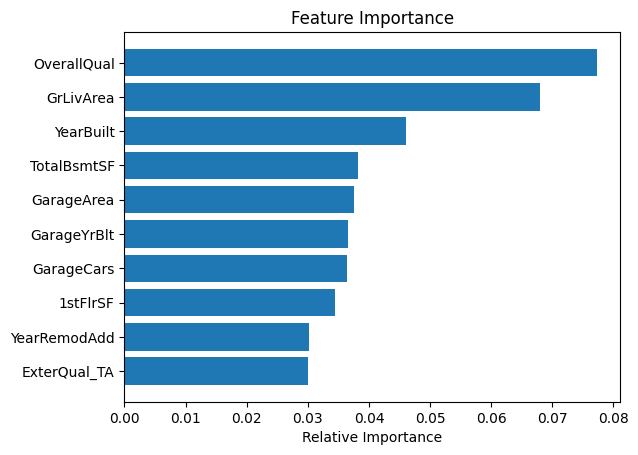

In [368]:
rfr = RandomForestRegressor(bootstrap=False, max_depth=20, max_features='sqrt', min_samples_split=2, min_samples_leaf=1, n_estimators=1000, n_jobs=-1, random_state=42)
rfr.fit(X_train_transformed, Y_train)
importance  = rfr.feature_importances_
features = X_train_transformed.columns

indices = np.argsort(importance)[-10:]

print(indices)
plt.title('Feature Importance')
plt.barh(range(len(indices)), importance[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [375]:
feature_importance = pd.DataFrame(rfr.feature_importances_, index=X_train_transformed.columns, columns=['importance']).sort_values(ascending=False, by='importance')
feature_importance = feature_importance[feature_importance['importance'] > 0.001]
print(feature_importance.shape)
feature_importance.head(40)

(100, 1)


,importance
OverallQual,0.077282
GrLivArea,0.067982
YearBuilt,0.046097
TotalBsmtSF,0.038253
GarageArea,0.037583
GarageYrBlt,0.036644
GarageCars,0.036419
1stFlrSF,0.034480
YearRemodAdd,0.030242
ExterQual_TA,0.030021


In [376]:
X_train_reduced = X_train_transformed[feature_importance.index]
X_test_reduced = X_test_transformed[feature_importance.index]

X_train_reduced.head()

,OverallQual,GrLivArea,YearBuilt,TotalBsmtSF,GarageArea,GarageYrBlt,GarageCars,1stFlrSF,YearRemodAdd,ExterQual_TA,...,BsmtFinSF2,ExterCond_Fa,ExterCond_TA,MasVnrType_Stone,LandContour_Bnk,Condition1_Norm,HeatingQC_Fa,SaleType_WD,MasVnrType_BrkFace,LotConfig_Inside
135,0.64319,0.310528,-0.054393,0.533770,0.261578,0.211829,0.290659,1.325399,-0.710452,1.0,...,-0.280615,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
1452,-0.82429,-0.861238,1.098468,-1.158455,0.237695,0.292168,0.290659,-0.248946,0.973103,1.0,...,-0.280615,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
1046,2.11067,2.588747,1.098468,2.071750,1.150049,0.292168,1.645741,2.125476,1.021204,0.0,...,-0.280615,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
691,2.84441,5.370249,0.736140,3.082167,1.704149,0.266919,1.645741,3.292040,0.492087,0.0,...,-0.280615,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
435,0.64319,0.270188,0.802018,-0.595125,0.357113,0.271509,0.290659,-0.881265,0.540189,0.0,...,1.936283,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [377]:
for name, cfg in models_config.items():
    print('\n' +'_'*10 + name + '_'*10 +'\n')

    y = Y_test.values.ravel() if cfg['ravel_y'] else Y_test

    model_scores(cfg['model'], cfg['params'], y, X_train_reduced, X_test_reduced)


__________LinearRegression__________

Runtime for grid search:  2.213170051574707
Best Accuracy Score: 
 0.8243647462150812
Best Parameters: 
 {'fit_intercept': True, 'n_jobs': -1, 'tol': np.float64(0.0001)}
Score: 
 0.883181408861539
Cross Validation Score: 
 [0.88219691 0.60328936 0.87334212 0.88905921 0.87393613]
Avarage Cross Validation Score: 
 0.8243647462150809
Root Mean Squared Error 24788.719593938335

__________KNN__________

Runtime for grid search:  0.5451865196228027
Best Accuracy Score: 
 0.812516230948565
Best Parameters: 
 {'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 10, 'p': 2, 'weights': 'distance'}
Score: 
 0.8257129468016017
Cross Validation Score: 
 [0.81756766 0.77886944 0.80659251 0.83100254 0.828549  ]
Avarage Cross Validation Score: 
 0.812516230948565
Root Mean Squared Error 34678.840728780124

__________RandomForest__________

Runtime for grid search:  652.6101729869843
Best Accuracy Score: 
 0.859381277688624
Best Parameters: 
 {'bootstrap': False, 

Original number of features: 254
Reduced number of features: 49


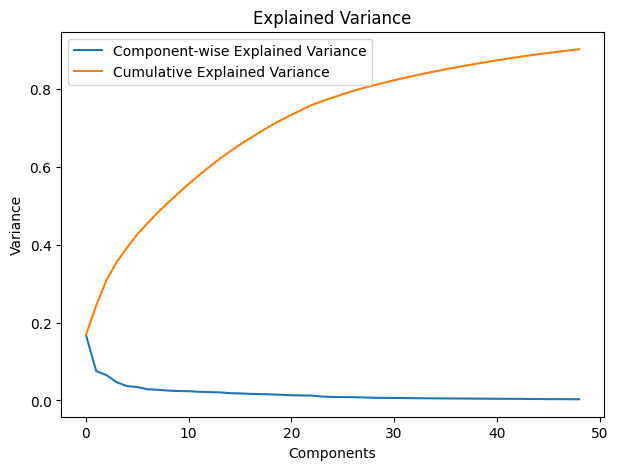

In [372]:
pca = PCA(n_components=0.90, whiten=True)

X_pca_train = pca.fit_transform(X_train_transformed)
X_pca_test = pca.transform(X_test_transformed)

print('Original number of features:', X_train_transformed.shape[1])
print('Reduced number of features:', X_pca_train.shape[1])

fig = plt.figure(figsize=(7,5))
ax = plt.subplot(111)
ax.plot(range(X_pca_train.shape[1]), pca.explained_variance_ratio_, label='Component-wise Explained Variance')
ax.plot(range(X_pca_train.shape[1]), np.cumsum(pca.explained_variance_ratio_), label='Cumulative Explained Variance')
plt.title('Explained Variance')
plt.xlabel('Components')
plt.ylabel('Variance')
ax.legend()
plt.show()

In [373]:
for name, cfg in models_config.items():
    print('\n' +'_'*10 + name + '_'*10 +'\n')

    y = Y_test.values.ravel() if cfg['ravel_y'] else Y_test

    model_scores(cfg['model'], cfg['params'], y, X_pca_train, X_pca_test)




__________LinearRegression__________

Runtime for grid search:  0.051763296127319336
Best Accuracy Score: 
 0.8120495744360754
Best Parameters: 
 {'fit_intercept': True, 'n_jobs': -1, 'tol': np.float64(0.0001)}
Score: 
 0.8915183102747068
Cross Validation Score: 
 [0.87728264 0.5431865  0.87515334 0.8813936  0.88323179]
Avarage Cross Validation Score: 
 0.8120495744360754
Root Mean Squared Error 24509.442404945057

__________KNN__________

Runtime for grid search:  0.3076930046081543
Best Accuracy Score: 
 0.7182750834976014
Best Parameters: 
 {'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Score: 
 0.7271966650551338
Cross Validation Score: 
 [0.73370577 0.7801629  0.66333092 0.72399566 0.69018017]
Avarage Cross Validation Score: 
 0.7182750834976014
Root Mean Squared Error 45413.25940877732

__________RandomForest__________

Runtime for grid search:  3358.251145839691
Best Accuracy Score: 
 0.8124982182154934
Best Parameters: 
 {'bootstrap': Fa